In [9]:
# import 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

import shap

In [10]:
# 데이터 불러오기
housing = fetch_california_housing()

# 입력 변수(feature)
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# 타겟 변수(집값)
y = pd.Series(housing.target, name='target')

In [11]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: target, Length: 20640, dtype: float64

In [12]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [13]:
# 모델 생성 및 학습
model = LGBMRegressor(
    n_estimators = 300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [14]:
# SHAP Explainer 생성
explainer = shap.TreeExplainer(model)

# shap value 계산 (학습 데이터가 아니라, 테스트 데이터 기준으로 계산)
shap_values = explainer.shap_values(X_test) # 각 feature가 얼마나 예측 했는지의 기여도를 스코어로 계산

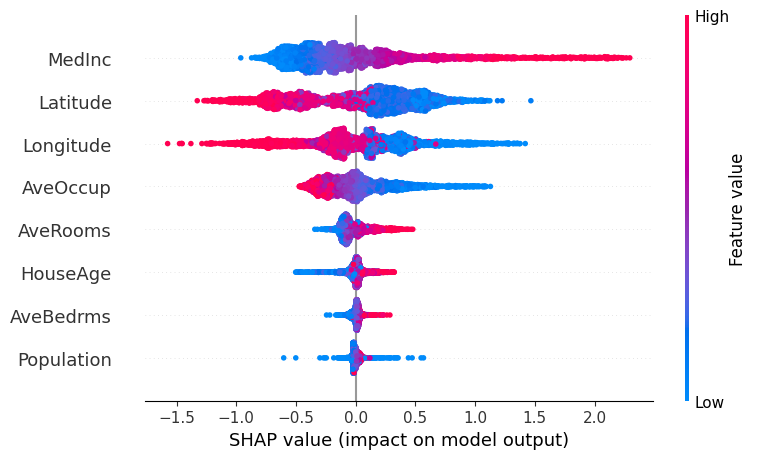

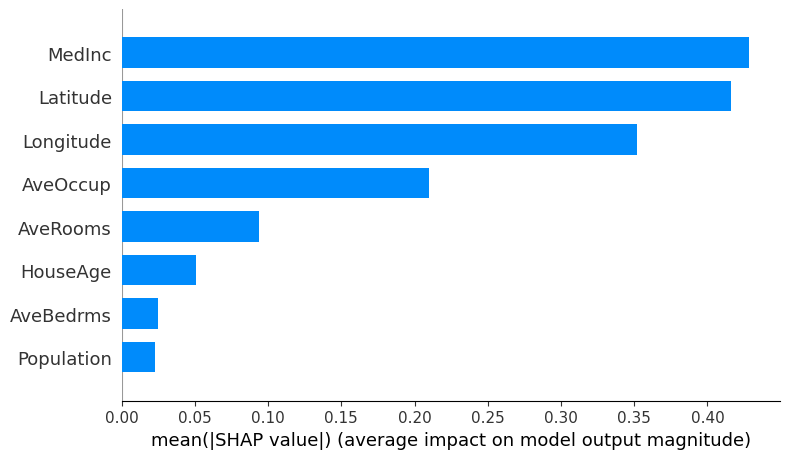

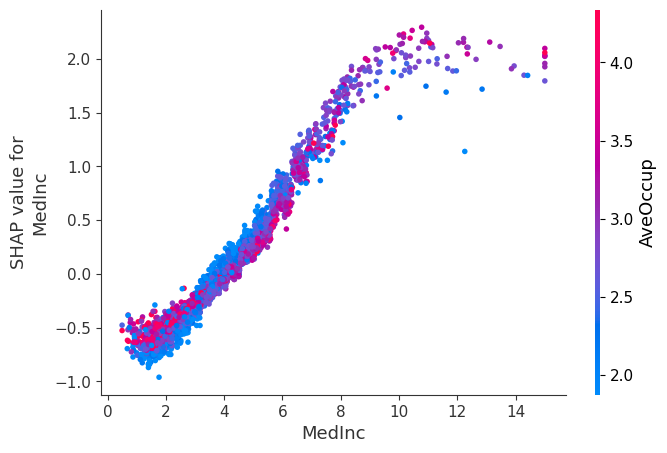

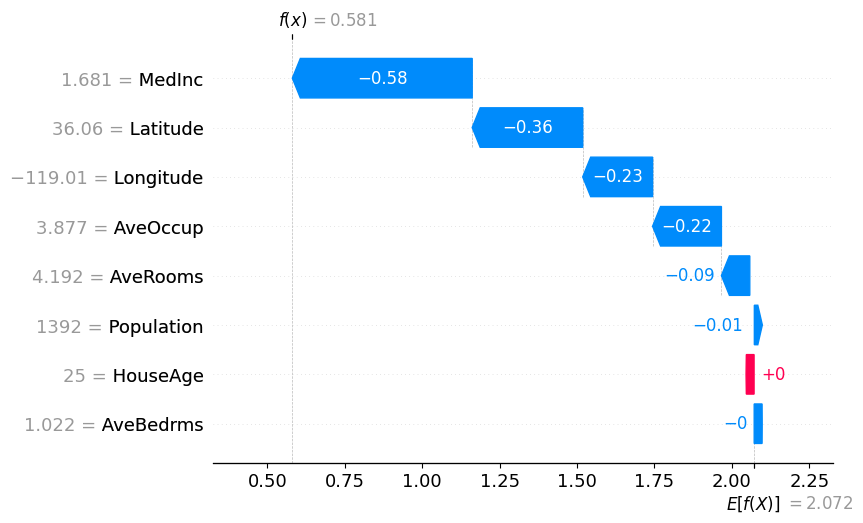


[SHAP 값 샘플]
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0 -0.580755  0.000887 -0.091632  -0.000387   -0.014700 -0.222255 -0.356787   
1 -0.491580  0.025925 -0.105208   0.053759    0.006504  0.003098 -0.472470   
2  0.038094  0.309970 -0.044298   0.054821   -0.020946  0.784144  0.244839   
3  0.515880 -0.017496  0.030108  -0.010587    0.000954 -0.339485  0.149926   
4 -0.096139  0.029217 -0.024359   0.007217   -0.008561  0.077057 -0.035779   

   Longitude  
0  -0.225686  
1  -0.192753  
2   1.419950  
3   0.001678  
4   0.496815  


In [15]:
# 매직 코드: 그래프가 한번에 쫙 보여지는 것이다.
%matplotlib inline

# 영향도 시각화
shap.summary_plot(shap_values, X_test) # 점 위치: 영향 방향(+/-), 색: feature 값 크기
# shap bar plot(방향성)
shap.summary_plot(shap_values, X_test, plot_type='bar')
# shap dependence plot
shap.dependence_plot("MedInc", shap_values, X_test)

# shap waterfall plot
sample_index = 0
# 개별 샘플 shap 값
shap.initjs() # 시각화 초기화
# 
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X.columns
    )
)

# Force plot (interactive)

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

# shap 값 직접 확인
shap_df = pd.DataFrame(shap_values, columns=X.columns)

print("\n[SHAP 값 샘플]")
print(shap_df.head())